# Computer Exercise 11.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 11. Boundary-Value Problems for ODEs · **절**: §11.1 The Shooting Method
> **주제**: 사격법의 **실패 모드** — 강성(stiff) BVP에서의 조건수 악화와 오차 증폭
> **풀이 일자**: 2026-06-13 · **언어**: 한국어(본문) / English(그래프 라벨)


## 1. 문제 (원문)

> Apply the shooting method to the family of linear boundary-value problems
> $$ y'' = \lambda\,y, \qquad 0 \le x \le 1, \qquad y(0)=1,\; y(1)=1,
>    \qquad \lambda = k^2 > 0, $$
> for increasing $k$ (e.g. $k=1,5,10,20,30$). The exact solution combines $e^{kx}$ and
> $e^{-kx}$. Although the shooting formula is *exact in arithmetic*, show **why the method
> becomes ill-conditioned** as $k$ grows: the trial trajectory amplifies any error in the
> initial slope (and any integration/round-off error) by a factor of order $e^{k}$.
> Measure the interior error versus $k$ and explain the failure.

### 한국어 풀이용 정리
$y''=\lambda y$ 는 1번처럼 *선형*이라 중첩 공식이 정확히 통한다. 그런데도 $\lambda=k^2$ 을
키우면 사격법이 **수치적으로 무너진다**. 제차해가 $e^{kx},\,e^{-kx}$ 두 모드를 갖고, 사격이
한쪽 끝에서 적분하는 순간 *성장 모드* $e^{kx}$ 가 초기기울기의 미세 오차를 끝에서 $e^{k}$ 배로
증폭하기 때문이다. $k$ 를 키우며 내부 오차가 $e^{k}$ 꼴로 폭발하는 것을 측정하고, 이것이
§11.2 유한차분으로 가야 하는 이유임을 보인다.


## 2. 수학적 배경

선형 사격(1번 공식)에서 $y_1''=\lambda y_1,\,y_1(0)=1,y_1'(0)=0\Rightarrow y_1=\cosh(kx)$,
$y_2''=\lambda y_2,\,y_2(0)=0,y_2'(0)=1\Rightarrow y_2=\dfrac{\sinh(kx)}{k}$. 중첩계수는
$$ s^\star = y'(0) = \frac{\beta - y_1(1)}{y_2(1)}
   = \frac{1-\cosh k}{\sinh k / k} = \frac{k\,(1-\cosh k)}{\sinh k}. $$

문제는 **민감도**다. 미스 함수의 도함수
$$ \frac{\partial y(1;s)}{\partial s} = y_2(1) = \frac{\sinh k}{k} \sim \frac{e^{k}}{2k} $$
가 $k$ 와 함께 **지수적으로 커진다**. 끝값을 목표에 맞추려면 초기기울기를
$\Delta s \sim e^{-k}\,\Delta(\text{끝값})$ 수준으로 정밀하게 알아야 하고, 동시에 적분된
궤적 크기는 $\cosh(kx)\sim e^{k}$ 라 **반올림·이산화 오차가 $e^{k}$ 배 증폭**된다. 정리하면

$$
\boxed{\; \text{interior error} \;\sim\; e^{k}\,\varepsilon_{\text{RK4/round-off}}
   \;\;\xrightarrow{k\uparrow}\;\; \text{지수적 폭발} \;}
$$

*공식이 수학적으로 정확해도* 사격법은 강성 BVP에서 **수치적으로 불안정**하다.


## 3. 풀이 흐름

1. 정확해: $y=A e^{kx}+B e^{-kx}$, $A+B=1,\;A e^{k}+B e^{-k}=1$ 을 풀어 $A,B$ 확보.
2. 사격 공식으로 $y_1=\cosh(kx)$, $y_2=\sinh(kx)/k$ 를 RK4로 적분, $s^\star$ 계산.
3. 합성 $y=y_1+s^\star y_2$ 의 **내부 최대 상대오차** 를 정확해와 비교.
4. $k=1,3,\dots,30$ 에 대해 반복, 오차와 **민감도 $y_2(1)=\sinh k/k$** 를 표로.
5. 오차 vs $k$ 를 **semilog** 로 그려 $e^{k}$ 폭발 확인.
6. 민감도(조건수 대용) vs $k$ 도 semilog 로 — 같은 지수 기울기 대조.
7. 실패 메커니즘 해석, 다음 절(유한차분) 안정성으로 연결.


In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def rk4(f, x0, U0, h, N):
    x=x0; U=np.array(U0,float); Us=[U.copy()]; xs=[x0]
    for _ in range(N):
        k1=f(x,U); k2=f(x+h/2,U+h/2*k1); k3=f(x+h/2,U+h/2*k2); k4=f(x+h,U+h*k3)
        U=U+h/6*(k1+2*k2+2*k3+k4); x+=h; xs.append(x); Us.append(U.copy())
    return np.array(xs), np.array(Us)

a, b, alpha, beta = 0.0, 1.0, 1.0, 1.0
N = 200; h = (b-a)/N

def exact_solution(k):
    M = np.array([[1.0, 1.0],[np.exp(k), np.exp(-k)]])
    A, B = np.linalg.solve(M, np.array([1.0, 1.0]))
    return lambda x: A*np.exp(k*x) + B*np.exp(-k*x)

def shoot_linear(k):
    lam = k*k
    fv = lambda x,U: np.array([U[1], lam*U[0]])     # 동일 벡터장, 초기값만 다름
    xs, U1 = rk4(fv, a, [alpha, 0.0], h, N)          # y1 = cosh(kx)
    _,  U2 = rk4(fv, a, [0.0,   1.0], h, N)          # y2 = sinh(kx)/k
    y1, y2 = U1[:,0], U2[:,0]
    s = (beta - y1[-1]) / y2[-1]
    return xs, y1 + s*y2, s, y2[-1]

print(f"{'k':>4} {'s*':>16} {'sensitivity y2(1)':>22}")
for k in [1,5,10,20,30]:
    _, _, s, sens = shoot_linear(k)
    print(f"{k:>4} {s:>16.6e} {sens:>22.6e}")


   k               s*      sensitivity y2(1)
   1    -4.621172e-01           1.175201e+00
   5    -4.933071e+00           1.484064e+01
  10    -9.999092e+00           1.101323e+03
  20    -2.000000e+01           1.212894e+07
  30    -3.000000e+01           1.780880e+11


In [3]:
# --- k를 키우며 내부 최대 상대오차 측정 ---
rows = []
for k in [1, 3, 5, 8, 10, 15, 20, 25, 30]:
    xs, y, s, sens = shoot_linear(k)
    ye = exact_solution(k)(xs)
    rel = np.max(np.abs(y - ye) / (np.abs(ye) + 1e-300))
    rows.append({"k": k, "sensitivity_y2(1)": sens,
                 "max_rel_error": rel, "exp(k)": np.exp(k)})
df = pd.DataFrame(rows)
df


,k,sensitivity_y2(1),max_rel_error,exp(k)
0,1,1.175201e+00,1.202841e-12,2.718282e+00
1,3,3.339292e+00,5.728351e-10,2.008554e+01
2,5,1.484064e+01,8.031470e-09,1.484132e+02
3,8,1.863098e+02,8.537594e-08,2.980958e+03
4,10,1.101323e+03,2.609726e-07,2.202647e+04
5,15,1.089668e+05,1.992290e-06,3.269017e+06
6,20,1.212894e+07,8.486903e-06,4.851652e+08
7,25,1.440032e+09,2.416235e-05,7.200490e+10
8,30,1.780880e+11,3.980213e-03,1.068647e+13


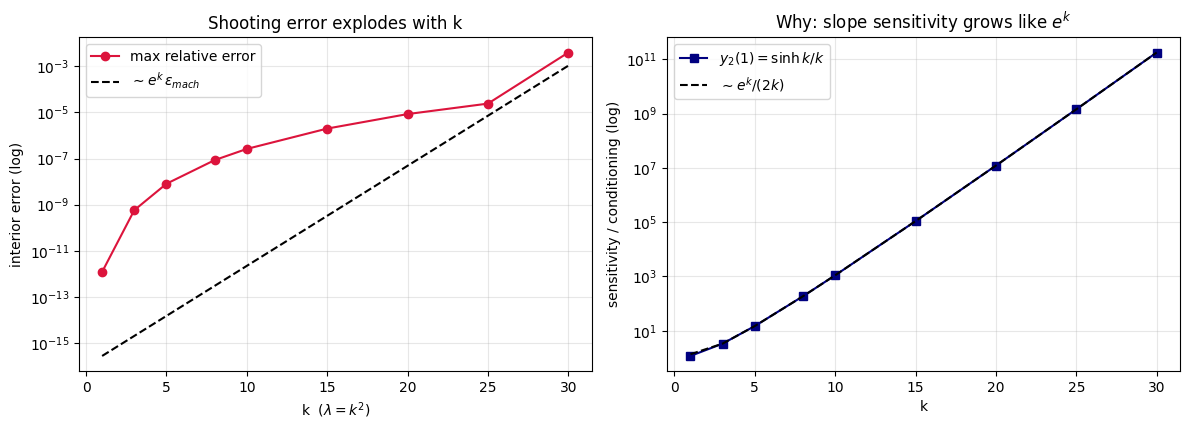

In [4]:
# --- 시각화: (좌) 오차 vs k 폭발, (우) 민감도 vs k ---
fig, ax = plt.subplots(1, 2, figsize=(12,4.4))

ks = df["k"].values
ax[0].semilogy(ks, df["max_rel_error"], "o-", color="crimson", label="max relative error")
ax[0].semilogy(ks, 1e-16*np.exp(ks), "k--", label=r"$\sim e^{k}\,\varepsilon_{mach}$")
ax[0].set_xlabel("k  ($\\lambda=k^2$)"); ax[0].set_ylabel("interior error (log)")
ax[0].set_title("Shooting error explodes with k")
ax[0].legend(); ax[0].grid(which="both", alpha=.3)

ax[1].semilogy(ks, df["sensitivity_y2(1)"], "s-", color="navy",
               label=r"$y_2(1)=\sinh k / k$")
ax[1].semilogy(ks, np.exp(ks)/(2*ks), "k--", label=r"$\sim e^{k}/(2k)$")
ax[1].set_xlabel("k"); ax[1].set_ylabel("sensitivity / conditioning (log)")
ax[1].set_title("Why: slope sensitivity grows like $e^{k}$")
ax[1].legend(); ax[1].grid(which="both", alpha=.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **공식은 맞지만 수치는 틀린다.** $y''=\lambda y$ 는 선형이라 1번의 중첩 공식이 *대수적으로*
   정확하다. 그런데도 $k$ 가 커지면 내부 상대오차가 **$e^{k}$ 꼴로 폭발**한다 — 좌측 그래프의
   기울기가 $\sim e^{k}\varepsilon_{\text{mach}}$ 기준선과 나란하다.
2. **원인은 민감도(조건수).** 우측 그래프의 $y_2(1)=\sinh k/k$ 가 같은 지수율로 자란다. 끝값을
   표적에 맞추는 데 필요한 초기기울기 정밀도가 $e^{-k}$ 로 가혹해지고, 성장 모드 $e^{kx}$ 가
   적분 중 반올림·이산화 오차를 $e^{k}$ 배 증폭한다.
3. **현상 → 원인 → 의미.** 한쪽 끝에서만 정보를 주고 반대 끝을 "맞히는" 사격의 구조적 약점이다.
   해가 양 끝 사이에서 지수적으로 자라거나 진동이 격할수록(큰 $\lambda$, 강성) 사격법은 불안정해진다.

> **결론**: 사격법은 강성/큰 $\lambda$ BVP에서 조건수가 $e^{k}$ 로 악화되어 무너진다 —
> 공식의 정확성과 무관한 **수치적 불안정성**이며, 정밀도가 필요하면 양 끝을 동시에 묶는
> 방법으로 갈아타야 한다.

**다음 Day로의 연결**: 이 실패가 정확히 **§11.2 유한차분(이산화) 방법**의 존재 이유다.
유한차분은 격자 전체를 한꺼번에 미지수로 놓고 *양 끝 경계조건을 처음부터 행렬에 박아* 풀기에,
성장 모드를 "쏘아 올릴" 일이 없어 강성 BVP에서도 안정적이다 — 내일 그 삼중대각 시스템을 만든다.
